In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

1) TEXT PREPROCESSING

In [ ]:
#import the data that has been scraped

df = pd.read_csv("macbook_neo_articles_2.csv")

In [ ]:
#combine title and body column for better sentiment accuracy

df["text"] = (
    df["Title"].fillna('') + " " +
    df["Body"].fillna('')
)

In [ ]:
pip install nltk

In [ ]:
#clean the text column

def clean_text(text):

    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove punctuation/numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df["clean_text"] = df["text"].apply(clean_text)

In [ ]:
import nltk
from nltk.corpus import stopwords

In [ ]:
#remove stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):

    words = text.split()

    filtered = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered)

df["clean_text"] = df["clean_text"].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
pip install spacy

In [ ]:
#lemmatization
import spacy

nlp = spacy.load("en_core_web_sm")

def lemmatize(text):

    doc = nlp(text)

    return " ".join(
        token.lemma_
        for token in doc
    )

df["clean_text"] = df["clean_text"].apply(lemmatize)

2) SENTIMENT SCORING

In [ ]:
pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.1 MB/s eta 0:00:00


In [ ]:
#initialize vader
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [ ]:
#generate sentiment score
df["compound_score"] = df["clean_text"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

In [ ]:
#convert score into labels
def classify_sentiment(score):

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["predicted_sentiment"] = df["compound_score"].apply(classify_sentiment)

In [ ]:
#save dataset
df.to_csv(
    "macbook_neo_sentiment_results.csv",
    index=False
)

3) INSIGHT GENERATION

In [ ]:
#sentiment distribution
print(df["predicted_sentiment"].value_counts())

predicted_sentiment
Positive    306
Negative     12
Neutral       3
Name: count, dtype: int64


The sentiment distribution shows that media coverage surrounding the MacBook Neo was overwhelmingly positive, with 306 out of 321 analyzed articles classified as positive. This suggests that most publishers viewed the product favorably.

In [ ]:
#average sentiment score
print(df["compound_score"].mean())

0.8570616822429907


3.1. Sentiment Overtime

In [ ]:
#sentiment overtime
df["Date"] = pd.to_datetime(df["Date"])

daily_sentiment = df.groupby(
    df["Date"].dt.date
)["compound_score"].mean()

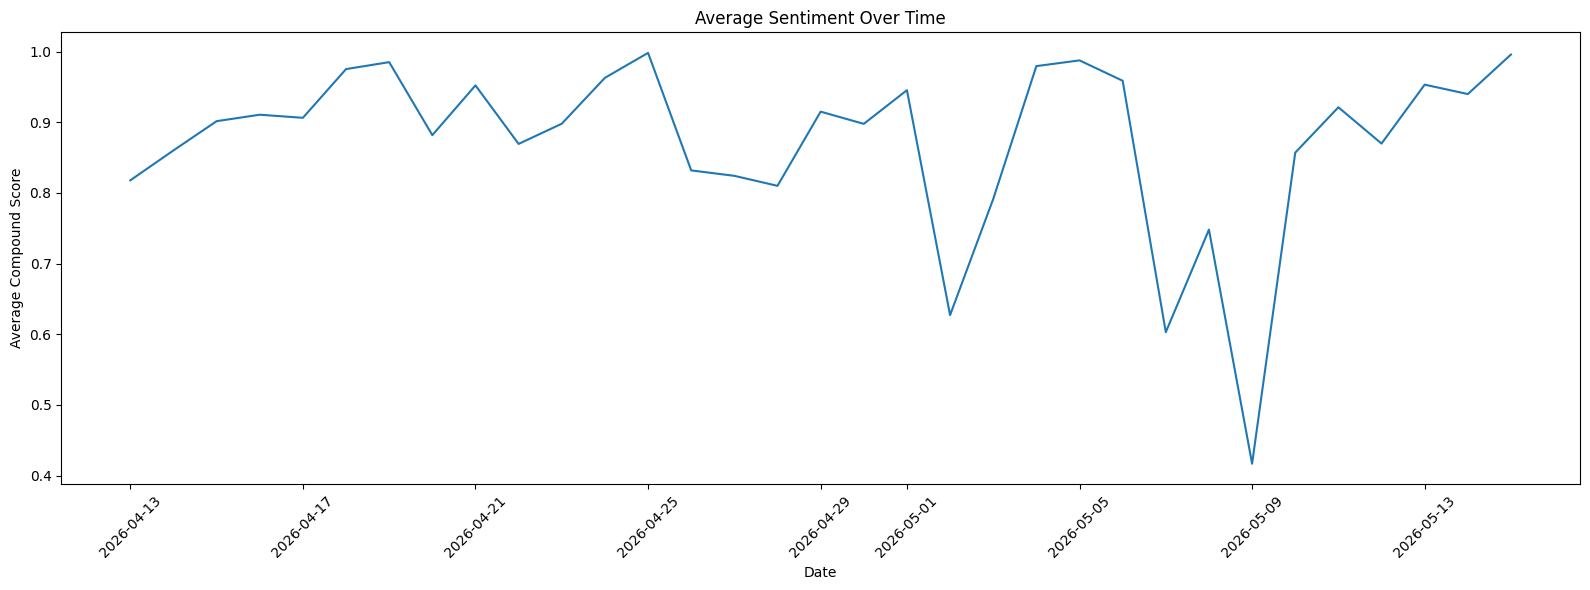

In [ ]:
plt.figure(figsize=(16, 6))

daily_sentiment.plot()

plt.title("Average Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Average Compound Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

3.1.1. Why Is Sentiment So Low In 2026-05-09

In [ ]:
target_date = "2026-05-09"

day_articles = df[
    df["Date"].dt.date.astype(str) == target_date
]

In [ ]:
lowest_articles = day_articles.sort_values(
    by="compound_score"
)

In [ ]:
print(
    lowest_articles[
        [
            "Date",
            "Source",
            "Title",
            "compound_score"
        ]
    ].head(10)
)

         Date                 Source  \
48 2026-05-09                  Stuff   
45 2026-05-09              TweakTown   
49 2026-05-09  The Financial Express   
46 2026-05-09                iLounge   
50 2026-05-09                 Gizbot   
47 2026-05-09             Gizmochina   
51 2026-05-09             topnews.in   

                                                Title  compound_score  
48  No, Apple won't increase the MacBook Neo price...         -0.8648  
45  Apple reportedly orders fresh A18 Pro silicon ...         -0.4588  
49  Apple MacBook Neo may get pricier as demand co...          0.5141  
46  Apple Looking to Add MacBook Neo To Deal with ...          0.8176  
50  MacBook Neo Price in India Discounted by Up to...          0.9532  
47  Apple turns to Intel to manufacture its next-g...          0.9623  
51  Apple's Budget MacBook Neo Demand Remains Stro...          0.9942  


In [ ]:
for index, row in lowest_articles.head(5).iterrows():

    print("\n====================")
    print("TITLE:", row["Title"])
    print("SCORE:", row["compound_score"])
    print("SOURCE:", row["Source"])

    print("\nBODY PREVIEW:")
    print(row["Body"][:1000])


TITLE: No, Apple won't increase the MacBook Neo price, unless it's gone mad | Stuff
SCORE: -0.8648
SOURCE: Stuff

BODY PREVIEW:
Much of the attraction of the MacBook Neo is its low price. Getting rid of that would be a bigger risk than releasing the Neo in the first place

I'm going to preface this column by noting something that's really quite important, given the headline: I can be comically bad at making tech predictions. Some years ago, at the dawn of my tech-writing career, I was quoted in MacUser arguing that the iPod wouldn't be a hit. In hindsight, I foreshadowed Steve Ballmer's infamous iPhone take. "I said that is the most expensive phone in the world and it doesn't appeal to business customers because it doesn't have a keyboard," he chortled. I was similarly all "this thing is very expensive and no one will want it". Nope. Nope, nope, nope.

What I'd failed to take into account was, well, everything. The iPod was a marvel. The device was pricier than most rival players, sur

In [ ]:
negative_text = " ".join(
    lowest_articles["clean_text"]
)

In [ ]:
from collections import Counter

words = negative_text.split()

word_counts = Counter(words)

print(word_counts.most_common(30))

[('apple', 92), ('neo', 66), ('macbook', 54), ('price', 35), ('chip', 32), ('production', 26), ('company', 23), ('demand', 21), ('supply', 17), ('may', 16), ('memory', 16), ('not', 15), ('laptop', 15), ('pro', 15), ('ai', 15), ('mac', 14), ('hardware', 14), ('device', 13), ('new', 13), ('gb', 13), ('reportedly', 12), ('market', 12), ('could', 12), ('consumer', 12), ('product', 11), ('also', 11), ('increase', 10), ('much', 10), ('one', 10), ('cost', 10)]


The sharp decline in sentiment on May 9, 2026 was primarily driven by media concerns regarding potential MacBook Neo price increases, supply shortages, and rising production costs despite strong consumer demand.

3.2. WORD CLOUD

In [ ]:
pip install scikit-learn

In [ ]:
from wordcloud import WordCloud, STOPWORDS

In [ ]:
custom_stopwords = set(STOPWORDS)

custom_stopwords.update([
    "macbook",
    "neo",
    "apple",
    "laptop",
    "device",
    "computer",
    "said",
    "also",
    "one",
    "would",
    "could",
    "us",
    "get",
    "may",
    "amazon",
    "air",
    "pro",
    "ipad",
    "ai",
    "app",
    "port",
    "video",
    "mac",
    "million",
    "unit",
    "wildcat",
    "lake",
    "tim",
    "cook",
    "say",
    "microsoft",
    "xbox",
    "gb",
    "model",
    "point",
    "supply",
    "chain",
    "intel",
    "lenovo",
    "hp",
    "ideapad",
    "window",
    "earning",
    "operating",
    "tag",
    "store"
])

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


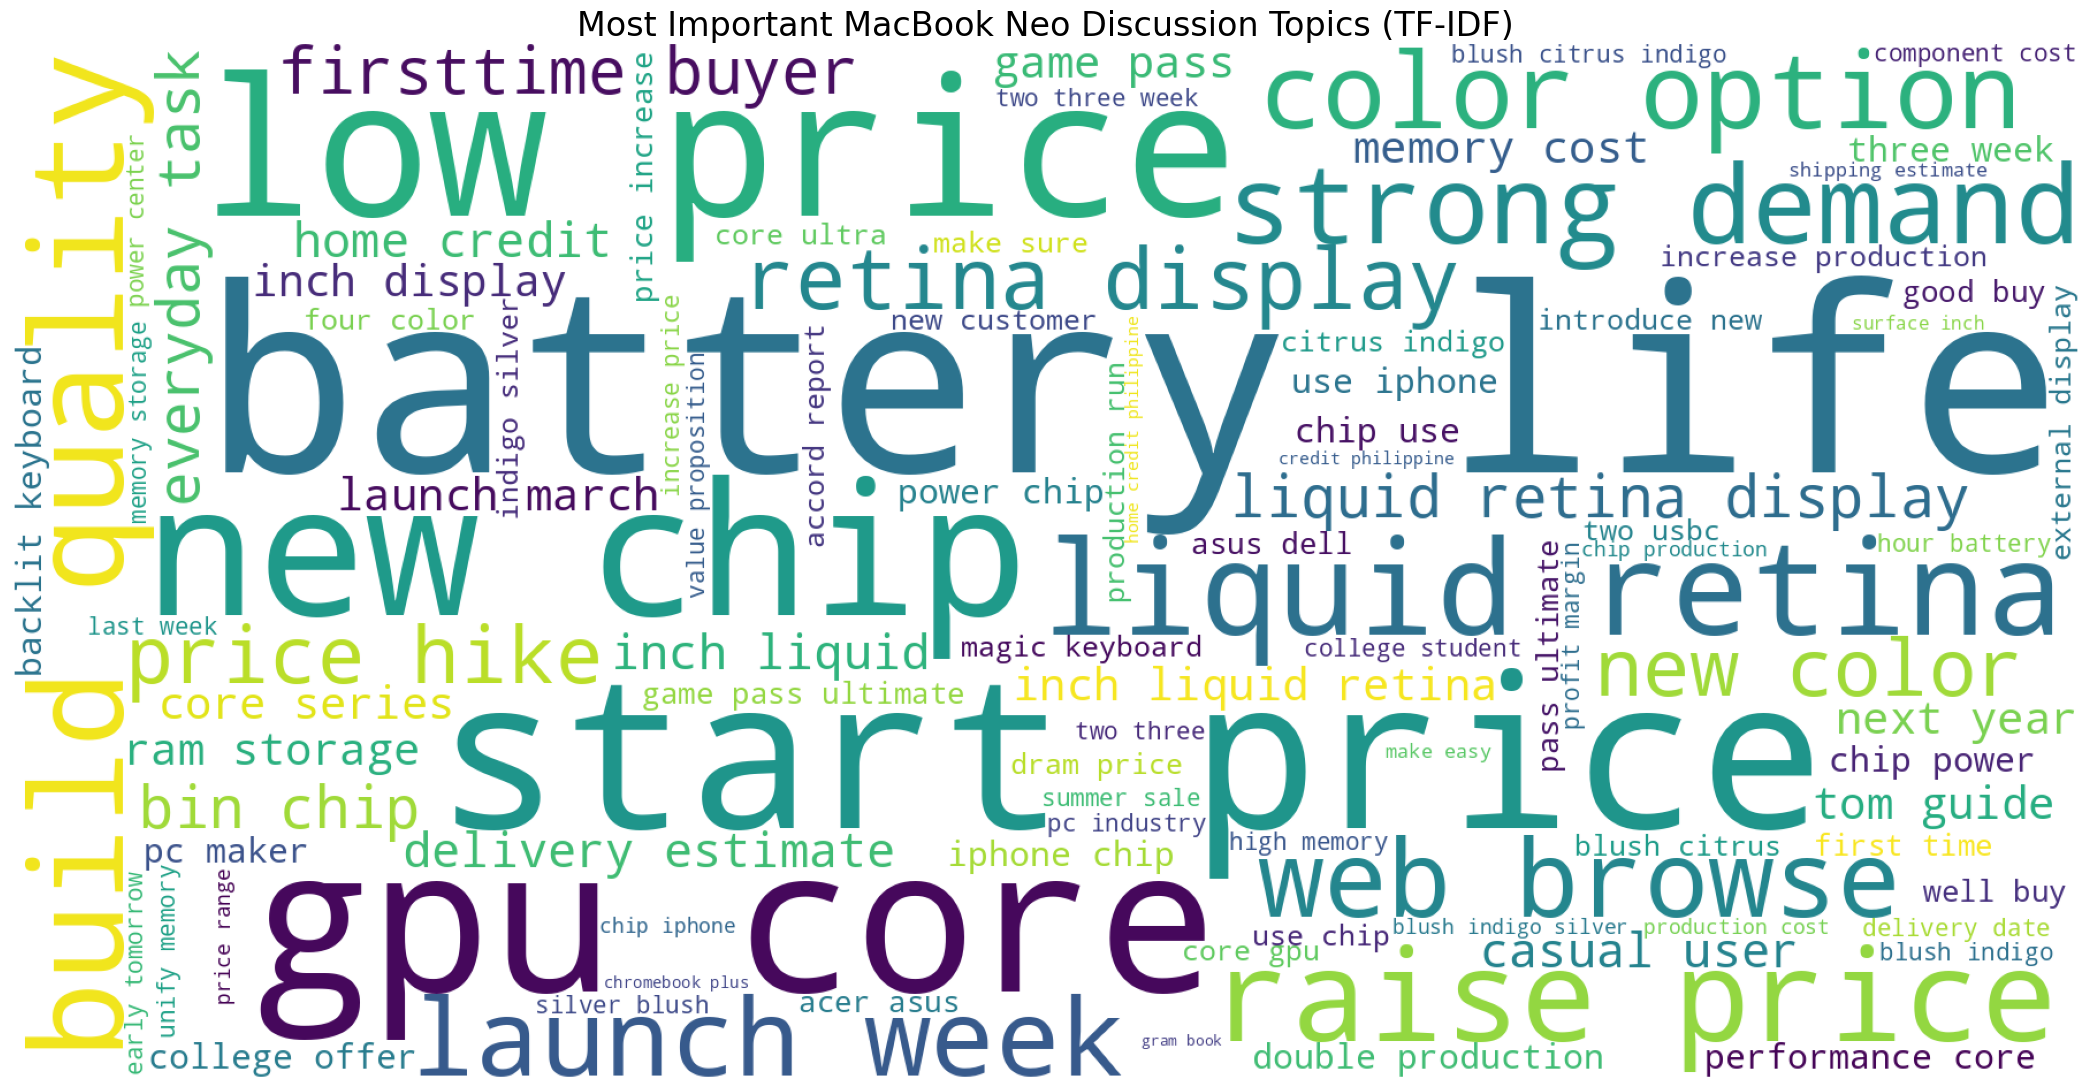

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

all_docs = df["clean_text"]

vectorizer = TfidfVectorizer(
    stop_words=list(custom_stopwords),

    # More meaningful phrases
    ngram_range=(2, 3),

    # Top keywords only
    max_features=100
)

X = vectorizer.fit_transform(all_docs)

scores = zip(
    vectorizer.get_feature_names_out(),
    X.sum(axis=0).tolist()[0]
)

word_scores = dict(scores)

wordcloud = WordCloud(
    width=1800,
    height=900,
    background_color="white",
    collocations=False
).generate_from_frequencies(word_scores)

plt.figure(figsize=(22, 11))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Most Important MacBook Neo Discussion Topics (TF-IDF)",
    fontsize=24
)

plt.tight_layout()

plt.show()

The TF-IDF word cloud highlights the dominant discussion themes surrounding the MacBook Neo across news coverage. The largest terms such as “battery life,” “low price,” “build quality,” “liquid retina,” and “new chip” indicate that media attention focused heavily on the device’s affordability, hardware performance, and display quality. Phrases like “raise price,” “price hike,” and “strong demand” suggest that pricing strategy and supply-demand concerns were also major topics during the product’s launch period. Additionally, terms such as “firsttime buyer,” “college student,” and “casual user” imply that the MacBook Neo was frequently positioned as an entry-level or budget-friendly laptop targeting mainstream consumers and students.

3.3. Which Article Sources Has The Best and Worst Sentiment

In [ ]:
#most positive sorces
positive_sources = df.groupby("Source")[
    "compound_score"
].mean().sort_values(ascending=False)

print("\nMOST POSITIVE SOURCES")
print("=" * 40)
print(positive_sources.head(10))

negative_sources = df.groupby("Source")[
    "compound_score"
].mean().sort_values(ascending=True)

print("\nMOST NEGATIVE SOURCES")
print("=" * 40)

print(negative_sources.head(10))


MOST POSITIVE SOURCES
Source
shopping.ndtvprofit.com    0.999800
PC Magazine                0.999500
Upgrade Magazine           0.999200
Silicon Valley             0.999000
TechRepublic               0.998400
DNyuz                      0.998200
Cord Cutters News          0.998200
Manila Standard            0.998080
Windows Central            0.998067
The Irish News             0.998000
Name: compound_score, dtype: float64

MOST NEGATIVE SOURCES
Source
O'Grady's PowerPage                                                                 -0.009400
Insomnia.gr                                                                          0.000000
TelecomTalk                                                                          0.077200
Tom's Guide                                                                          0.307443
VnExpress International – Latest news, business, travel and analysis from Vietnam    0.394100
Stuff                                                                    

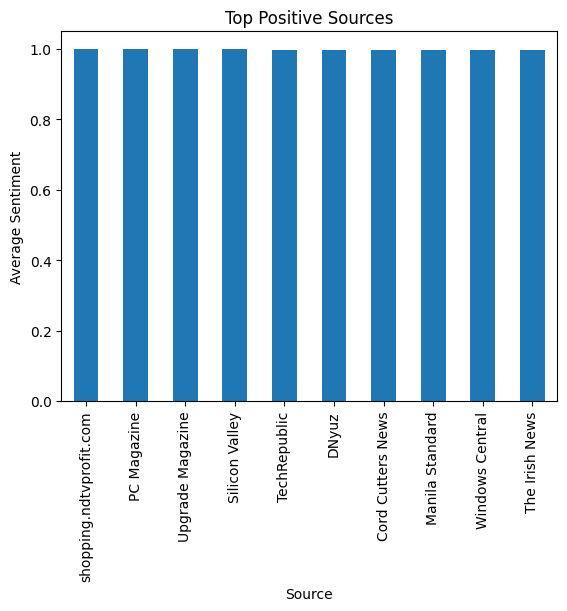

In [ ]:
positive_sources.head(10).plot(
    kind="bar"
)

plt.title("Top Positive Sources")

plt.ylabel("Average Sentiment")

plt.show()

In [ ]:
top_10_positive_sources = (
    df.groupby("Source")["compound_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

print("TOP 10 POSITIVE SOURCES:")
print(top_10_positive_sources)

TOP 10 POSITIVE SOURCES:
Index(['shopping.ndtvprofit.com', 'PC Magazine', 'Upgrade Magazine',
       'Silicon Valley', 'TechRepublic', 'DNyuz', 'Cord Cutters News',
       'Manila Standard', 'Windows Central', 'The Irish News'],
      dtype='object', name='Source')


In [ ]:
positive_source_articles = df[
    df["Source"].isin(top_10_positive_sources)
]

print("\nTotal Articles:")
print(len(positive_source_articles))


Total Articles:
16


In [ ]:
positive_source_articles = positive_source_articles.sort_values(
    by="compound_score",
    ascending=False
)

In [ ]:
for index, row in positive_source_articles.head(10).iterrows():

    print("\n====================")
    print("TITLE:", row["Title"])
    print("SCORE:", row["compound_score"])

    print("\nBODY PREVIEW:")
    print(row["Body"][:1200])


TITLE: Apple MacBook Neo 13 Inch A18 Pro Review: Features, Performance And Value
SCORE: 0.9998

BODY PREVIEW:
Apple continues to push the boundaries of innovation, and the MacBook Neo 13 inch with the A18 Pro chip is a strong testament to that ambition. Designed for modern users who demand speed, intelligence and seamless connectivity, this laptop brings together advanced hardware and intelligent software features. With Apple Intelligence built into its core, alongside a vibrant Liquid Retina display and sleek Indigo finish, the MacBook Neo aims to redefine everyday computing. It is positioned as a smart, efficient solution for both work and entertainment in an increasingly AI driven world.

Work Smarter, Create Faster With Apple's AI Powered MacBook Neo

Photo Credit: Amazon

As consumer expectations evolve, laptops are no longer just productivity tools but personal digital assistants that anticipate needs and enhance workflows. The MacBook Neo stands out by integrating AI powered fe

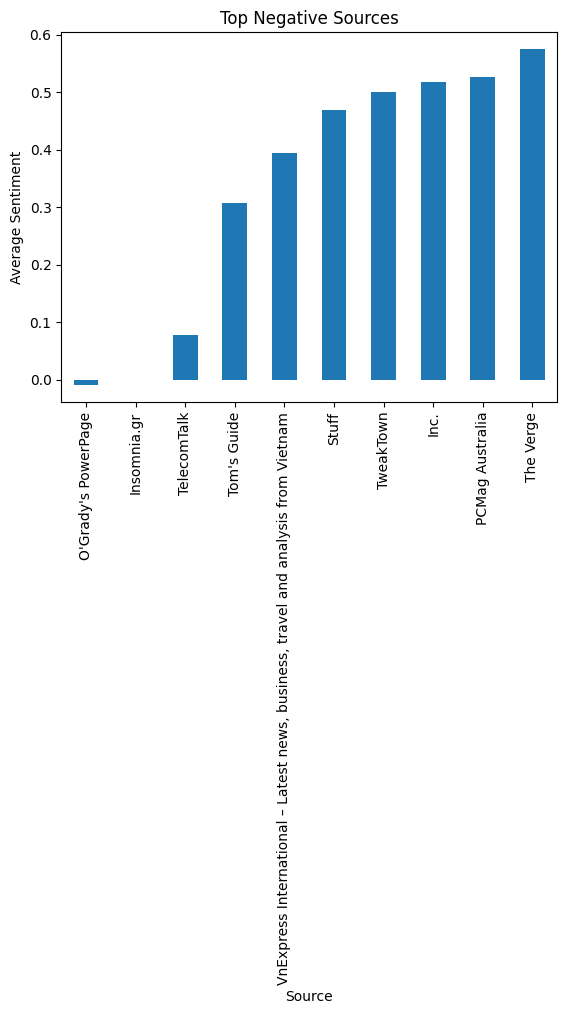

In [ ]:
negative_sources.head(10).plot(
    kind="bar"
)

plt.title("Top Negative Sources")

plt.ylabel("Average Sentiment")

plt.show()

In [ ]:
top_10_negative_sources = (
    df.groupby("Source")["compound_score"]
    .mean()
    .sort_values(ascending=True)
    .head(10)
    .index
)

print("TOP 10 NEGATIVE SOURCES:")
print(top_10_negative_sources)

TOP 10 NEGATIVE SOURCES:
Index(['O'Grady's PowerPage', 'Insomnia.gr', 'TelecomTalk', 'Tom's Guide',
       'VnExpress International – Latest news, business, travel and analysis from Vietnam',
       'Stuff', 'TweakTown', 'Inc.', 'PCMag Australia', 'The Verge'],
      dtype='object', name='Source')


In [ ]:
negative_source_articles = df[
    df["Source"].isin(top_10_negative_sources)
]

print("\nTotal Articles:")
print(len(negative_source_articles))


Total Articles:
25


In [ ]:
negative_source_articles = negative_source_articles.sort_values(
    by="compound_score",
    ascending=True
)

In [ ]:
for index, row in negative_source_articles.head(10).iterrows():

    print("\n====================")
    print("TITLE:", row["Title"])
    print("SCORE:", row["compound_score"])

    print("\nBODY PREVIEW:")
    print(row["Body"][:1200])


TITLE: Apple just 'doubled' MacBook Neo production but its budget laptop could still face a price hike -- here's why
SCORE: -0.9423

BODY PREVIEW:
If you're interested in the MacBook Neo, we've got some good news and potentially some bad news.

First, the good news: Apple is reportedly planning to produce more than double the number of MacBook Neos it originally estimated. In early April, the Neo proved so popular that initial inventory was exhausted, and Apple resorted to rush orders to maintain stock.

Even now, attempting to order a MacBook Neo directly from Apple shows delivery times from 2 to 3 weeks. Amazon, which seems to have more availability, lists up to a week for some variants, while others are available the next day.

"The customer response to MacBook Neo had just been off the charts, with higher-than-expected demand." Apple CEO Tim Cook said during the company's recent earnings call. He went on to say that the company is "supply constrained" on the Neo.

To combat that d

The most positive articles generally portrayed the MacBook Neo as a breakthrough budget laptop that successfully combines Apple’s premium ecosystem with affordability. Positive coverage heavily emphasized features such as strong battery life, premium build quality, AI-powered capabilities, attractive pricing, and accessibility for students or first-time Apple buyers. Many articles also adopted promotional or review-style language, using enthusiastic terms like “excellent,” “premium,” “best value,” and “game changer,” which contributed to extremely high sentiment scores. Overall, the positive media narrative focused on the MacBook Neo as a highly desirable and disruptive product in the budget laptop market.

In contrast, the most negative articles did not necessarily criticize the MacBook Neo’s quality, but instead focused on concerns surrounding supply shortages, production constraints, rising component costs, and potential future price increases. Negative sentiment was largely driven by uncertainty-related language such as “risk,” “shortage,” “delays,” “price hike,” and “discontinued.” Several articles highlighted fears that Apple may abandon the Neo’s affordable pricing strategy due to increasing RAM and chip costs. This indicates that negative sentiment was driven more by market and supply-chain concerns rather than dissatisfaction with the product itself.

4. CONCLUSION

The sentiment analysis indicates that media coverage of the MacBook Neo was overwhelmingly positive, with most articles highlighting its affordability, premium design, strong performance, and appeal to first-time Apple users. The device was frequently positioned as a high-value budget laptop capable of competing with Windows laptops and Chromebooks in the mainstream market. Meanwhile, the relatively small amount of negative coverage was driven mainly by external concerns such as supply shortages, rising component costs, and potential price increases rather than criticism of the product itself. Overall, the findings suggest that public and media perception of the MacBook Neo remained strongly favorable throughout the analyzed period, with concerns focused more on Apple’s ability to maintain supply and affordability amid growing demand.